# OptiClean - Stage 2: Loyalty Segmentation and Optimization

This notebook implements the Stage 2 approach: loyalty EDA, loyalty classification, segmented demand prediction, optimization, and comparison with Stage 1.

## 0. Imports and Data Loading

In [32]:
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    r2_score,
    roc_auc_score,
    roc_curve,
    root_mean_squared_error,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from opticlean_optimization import solve_location_model





DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")

FEATURES = [
    "employes",
    "surface",
    "firm_age",
    "monthly_volume",
    "purchase_staff",
    "dist_retail_point",
]

LOYALTY_LABELS = {0: "Non-Loyal", 1: "Loyal"}
LOYALTY_COLORS = {0: "#4878D0", 1: "#EE854A"}
DEMAND_COLORS = {"Loyal": "#EE854A", "Non-Loyal": "#4878D0"}
SITE_COLORS = [
    "#E41A1C",
    "#377EB8",
    "#4DAF4A",
    "#984EA3",
    "#FF7F00",
    "#A65628",
    "#F781BF",
    "#AAAAAA",
]
UNASSIGNED_COLOR = "#DDDDDD"


def format_site_id(site_id):
    if isinstance(site_id, str):
        label = site_id.strip()
        if label.startswith("Site "):
            return label
        if label.startswith("S") and label[1:].isdigit():
            return f"Site {int(label[1:])}"
        if label.isdigit():
            return f"Site {int(label) + 1}"
        return label
    return f"Site {int(site_id) + 1}"


def site_sort_key(site_id):
    label = format_site_id(site_id)
    try:
        return int(label.replace("Site ", ""))
    except ValueError:
        return label


def load_data():
    historic = pd.read_excel(DATA_DIR / "historic_clients.xlsx")
    potential = pd.read_excel(DATA_DIR / "potential_clients.xlsx")
    sites = pd.read_excel(DATA_DIR / "candidate_sites.xlsx")
    return historic, potential, sites


def compute_distance_matrix(clients_df, sites_df):
    lats = clients_df["lat"].values[:, None]
    lons = clients_df["lon"].values[:, None]
    site_lats = sites_df["lat"].values[None, :]
    site_lons = sites_df["lon"].values[None, :]
    return np.sqrt((lats - site_lats) ** 2 + (lons - site_lons) ** 2)


def matrix_to_dataframe(matrix, row_prefix="Client", col_prefix="Site"):
    return pd.DataFrame(
        matrix,
        index=[f"{row_prefix}_{i + 1}" for i in range(matrix.shape[0])],
        columns=[f"{col_prefix}_{j + 1}" for j in range(matrix.shape[1])],
    )


def demand_summary(df):
    return (
        df.groupby("loyal")["demand"]
        .agg(n="count", mean="mean", median="median", std="std", min="min", max="max")
        .rename(index=LOYALTY_LABELS)
        .round(2)
    )


def plot_demand_distribution(df):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for value, label in LOYALTY_LABELS.items():
        axes[0].hist(
            df[df["loyal"] == value]["demand"],
            bins=30,
            alpha=0.6,
            color=LOYALTY_COLORS[value],
            label=label,
        )
    axes[0].set_title("Demand Distribution")
    axes[0].set_xlabel("Weekly Demand")
    axes[0].set_ylabel("Count")
    axes[0].legend()

    groups = [df[df["loyal"] == value]["demand"].values for value in [0, 1]]
    boxplot = axes[1].boxplot(groups, tick_labels=list(LOYALTY_LABELS.values()), patch_artist=True)
    for patch, color in zip(boxplot["boxes"], LOYALTY_COLORS.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[1].set_title("Demand Box Plot")
    axes[1].set_ylabel("Weekly Demand")

    plt.tight_layout()
    return fig


def distance_sensitivity_table(df):
    rows = []
    for value, label in LOYALTY_LABELS.items():
        sub = df[df["loyal"] == value]
        x, y = sub["dist_retail_point"].values, sub["demand"].values
        rows.append(
            {
                "Group": label,
                "Pearson r": round(np.corrcoef(x, y)[0, 1], 3),
                "Slope (demand / dist unit)": round(np.polyfit(x, y, 1)[0], 3),
            }
        )
    return pd.DataFrame(rows).set_index("Group")


def plot_demand_vs_distance(df):
    fig, ax = plt.subplots(figsize=(10, 5))

    for value, label in LOYALTY_LABELS.items():
        sub = df[df["loyal"] == value]
        ax.scatter(
            sub["dist_retail_point"],
            sub["demand"],
            alpha=0.35,
            s=18,
            color=LOYALTY_COLORS[value],
            label=label,
        )
        coef = np.polyfit(sub["dist_retail_point"], sub["demand"], 1)
        x_line = np.linspace(sub["dist_retail_point"].min(), sub["dist_retail_point"].max(), 200)
        r = np.corrcoef(sub["dist_retail_point"], sub["demand"])[0, 1]
        ax.plot(
            x_line,
            np.polyval(coef, x_line),
            color=LOYALTY_COLORS[value],
            linewidth=2,
            label=f"{label} fit (r = {r:.2f})",
        )

    ax.set_xlabel("Distance to Retail Point")
    ax.set_ylabel("Weekly Demand")
    ax.set_title("Demand vs Distance by Loyalty Group")
    ax.legend()
    plt.tight_layout()
    return fig


def feature_means(df):
    features = [
        "employes",
        "surface",
        "firm_age",
        "monthly_volume",
        "purchase_staff",
        "dist_retail_point",
    ]
    return df.groupby("loyal")[features].mean().rename(index=LOYALTY_LABELS).round(2)


def plot_feature_comparison(df):
    features = ["employes", "surface", "firm_age", "monthly_volume", "purchase_staff"]
    fig, axes = plt.subplots(1, len(features), figsize=(15, 5))

    for ax, feature in zip(axes, features):
        groups = [df[df["loyal"] == value][feature].values for value in [0, 1]]
        boxplot = ax.boxplot(groups, tick_labels=list(LOYALTY_LABELS.values()), patch_artist=True)
        for patch, color in zip(boxplot["boxes"], LOYALTY_COLORS.values()):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax.set_title(feature.replace("_", " ").title())

    plt.suptitle("Client Features by Loyalty Group", fontsize=13)
    plt.tight_layout()
    return fig


def split_loyalty_data(historic, test_size=0.2, random_state=42):
    X = historic[FEATURES]
    y = historic["loyal"]
    return train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )


def train_classifiers(X_train, y_train):
    lr = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=1000,
                    random_state=42,
                ),
            ),
        ]
    )
    rf = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
    )
    lr.fit(X_train, y_train)
    rf.fit(X_train, y_train)
    return lr, rf


def train_final_classifier(historic):
    model = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=1000,
                    random_state=42,
                ),
            ),
        ]
    )
    return model.fit(historic[FEATURES], historic["loyal"])


def classification_evaluation_report(models, names, X_test, y_test):
    for model, name in zip(models, names):
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
        print(f"{'=' * 40}")
        print(f" {name}   (ROC AUC = {auc:.3f})")
        print(f"{'=' * 40}")
        print(classification_report(y_test, y_pred, target_names=["Non-Loyal", "Loyal"]))


def plot_confusion_matrices(models, names, X_test, y_test):
    fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
    if len(models) == 1:
        axes = [axes]

    for model, name, ax in zip(models, names, axes):
        cm = confusion_matrix(y_test, model.predict(X_test))
        ax.imshow(cm, cmap="Blues")
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Non-Loyal", "Loyal"])
        ax.set_yticklabels(["Non-Loyal", "Loyal"])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title(name)
        thresh = cm.max() / 2
        for i in range(2):
            for j in range(2):
                ax.text(
                    j,
                    i,
                    cm[i, j],
                    ha="center",
                    va="center",
                    fontsize=14,
                    color="white" if cm[i, j] > thresh else "black",
                )

    plt.suptitle("Confusion Matrices", fontsize=13)
    plt.tight_layout()
    return fig


def plot_roc_curves(models, names, X_test, y_test):
    fig, ax = plt.subplots(figsize=(6, 5))
    for model, name in zip(models, names):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        ax.plot(fpr, tpr, linewidth=2, label=f"{name}  (AUC = {auc:.2f})")
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random baseline")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves")
    ax.legend()
    plt.tight_layout()
    return fig


def build_loyalty_matrix(model, potential_df, sites_df):
    dist_matrix = compute_distance_matrix(potential_df, sites_df)
    base = potential_df[
        ["employes", "surface", "firm_age", "monthly_volume", "purchase_staff"]
    ].values
    loyalty_matrix = np.zeros((len(potential_df), len(sites_df)), dtype=int)

    for j in range(len(sites_df)):
        X = pd.DataFrame(
            np.column_stack([base, dist_matrix[:, j]]),
            columns=FEATURES,
        )
        loyalty_matrix[:, j] = model.predict(X)

    return loyalty_matrix


def save_loyalty_matrix(loyalty_matrix):
    OUTPUT_DIR.mkdir(exist_ok=True)
    path = OUTPUT_DIR / "loyalty_matrix_stage2.xlsx"
    matrix_to_dataframe(loyalty_matrix).to_excel(path)
    return path


def plot_loyalty_matrix_summary(loyalty_matrix):
    n_sites = loyalty_matrix.shape[1]
    loyal_counts = loyalty_matrix.sum(axis=0)
    nonloyal_counts = loyalty_matrix.shape[0] - loyal_counts
    x = np.arange(n_sites)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(x, nonloyal_counts, label="Non-Loyal", color=LOYALTY_COLORS[0], alpha=0.8)
    ax.bar(
        x,
        loyal_counts,
        bottom=nonloyal_counts,
        label="Loyal",
        color=LOYALTY_COLORS[1],
        alpha=0.8,
    )
    ax.set_xticks(x)
    ax.set_xticklabels([f"Site {j + 1}" for j in range(n_sites)])
    ax.set_ylabel("Potential Clients")
    ax.set_title("Predicted Loyalty Distribution per Candidate Site")
    ax.legend()
    plt.tight_layout()
    return fig


def split_by_loyalty(historic):
    loyal = historic[historic["loyal"] == 1].reset_index(drop=True)
    nonloyal = historic[historic["loyal"] == 0].reset_index(drop=True)
    return loyal, nonloyal


def get_demand_splits(loyal, nonloyal, test_size=0.2, random_state=42):
    splits = {}
    for name, df in [("Loyal", loyal), ("Non-Loyal", nonloyal)]:
        splits[name] = train_test_split(
            df[FEATURES],
            df["demand"],
            test_size=test_size,
            random_state=random_state,
        )
    return splits


def train_demand_models(splits):
    models = {}
    for name, (X_train, _, y_train, _) in splits.items():
        models[name] = LinearRegression().fit(X_train, y_train)
    return models


def train_final_demand_models(loyal, nonloyal):
    models = {}
    for name, df in [("Loyal", loyal), ("Non-Loyal", nonloyal)]:
        models[name] = LinearRegression().fit(df[FEATURES], df["demand"])
    return models


def demand_evaluation_report(models, splits):
    print(f"{'Group':<12} {'R2':>6}  {'RMSE':>7}")
    print("-" * 28)
    for name, model in models.items():
        _, X_test, _, y_test = splits[name]
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        rmse = root_mean_squared_error(y_test, y_pred)
        print(f"{name:<12} {r2:>6.3f}  {rmse:>7.2f}")


def plot_predictions_vs_actual(models, splits):
    fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
    if len(models) == 1:
        axes = [axes]

    for ax, (name, model) in zip(axes, models.items()):
        _, X_test, _, y_test = splits[name]
        y_pred = np.clip(model.predict(X_test), 0, None)
        lim = (
            min(y_test.min(), y_pred.min()) - 2,
            max(y_test.max(), y_pred.max()) + 2,
        )
        ax.scatter(y_test, y_pred, alpha=0.5, s=20, color=DEMAND_COLORS[name])
        ax.plot(lim, lim, "k--", linewidth=1)
        ax.set_xlim(lim)
        ax.set_ylim(lim)
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.set_title(f"{name} model")

    plt.suptitle("Predicted vs Actual Demand", fontsize=13)
    plt.tight_layout()
    return fig


def build_demand_matrix(models, loyalty_matrix, potential_df, sites_df):
    dist_matrix = compute_distance_matrix(potential_df, sites_df)
    base = potential_df[
        ["employes", "surface", "firm_age", "monthly_volume", "purchase_staff"]
    ].values
    demand_matrix = np.zeros((len(potential_df), len(sites_df)))

    for j in range(len(sites_df)):
        X = pd.DataFrame(
            np.column_stack([base, dist_matrix[:, j]]),
            columns=FEATURES,
        )
        loyal_mask = loyalty_matrix[:, j] == 1
        if loyal_mask.any():
            demand_matrix[loyal_mask, j] = models["Loyal"].predict(X[loyal_mask])
        if (~loyal_mask).any():
            demand_matrix[~loyal_mask, j] = models["Non-Loyal"].predict(X[~loyal_mask])

    return np.clip(demand_matrix, 0, None)


def save_demand_matrix(demand_matrix, filename="demand_matrix_stage2.xlsx"):
    OUTPUT_DIR.mkdir(exist_ok=True)
    path = OUTPUT_DIR / filename
    matrix_to_dataframe(demand_matrix).round(2).to_excel(path)
    return path


def plot_demand_matrix_summary(demand_matrix):
    x = np.arange(demand_matrix.shape[1])
    labels = [f"Site {j + 1}" for j in range(len(x))]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(x, demand_matrix.mean(axis=0), color=DEMAND_COLORS["Non-Loyal"], alpha=0.8)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels)
    axes[0].set_ylabel("Mean predicted demand")
    axes[0].set_title("Average demand per site")

    axes[1].bar(x, demand_matrix.sum(axis=0), color=DEMAND_COLORS["Loyal"], alpha=0.8)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].set_ylabel("Total predicted demand")
    axes[1].set_title("Total potential demand per site")

    plt.tight_layout()
    return fig


def run_optimization(demand_matrix, sites, budget=850, verbose=True):
    return solve_location_model(demand_matrix, sites, budget=budget, verbose=verbose)


def print_summary(result, total_clients=200):
    selected_sites = result["selected_sites"]
    print(f"Total captured demand : {result['objective_value']:.1f} units/week")
    print(f"Budget used           : {result['budget_used']:.0f} / 850 kEUR")
    print(f"Clients assigned      : {len(result['assignments'])} / {total_clients}")
    print(f"Clients unassigned    : {len(result['unassigned_clients'])}")
    print()
    display_cols = [
        "site_id",
        "format",
        "capacity",
        "cost",
        "used_capacity",
        "capacity_utilization",
    ]
    print(selected_sites[display_cols].to_string(index=False))


def save_optimization_results(result, filename):
    OUTPUT_DIR.mkdir(exist_ok=True)
    path = OUTPUT_DIR / filename
    with pd.ExcelWriter(path) as writer:
        result["selected_sites"].to_excel(writer, sheet_name="selected_sites", index=False)
        result["assignments"].to_excel(writer, sheet_name="assignments", index=False)
    return path


def load_optimization_results(filename):
    path = OUTPUT_DIR / filename
    selected_sites = pd.read_excel(path, sheet_name="selected_sites")
    assignments = pd.read_excel(path, sheet_name="assignments")
    assigned_clients = set(assignments["client_id"]) if not assignments.empty else set()
    unassigned_clients = [i for i in range(200) if i not in assigned_clients]

    return {
        "selected_sites": selected_sites,
        "assignments": assignments,
        "unassigned_clients": unassigned_clients,
        "objective_value": float(assignments["captured_demand"].sum()) if not assignments.empty else 0.0,
        "budget_used": float(selected_sites["cost"].sum()) if not selected_sites.empty else 0.0,
    }


def plot_capacity_utilization(result, title):
    selected_sites = result["selected_sites"]
    labels = [
        f"{format_site_id(row['site_id'])}\n({row['format'][0].upper()})"
        for _, row in selected_sites.iterrows()
    ]
    x = range(len(selected_sites))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x, selected_sites["capacity"], color="#BBBBBB", alpha=0.6, label="Total capacity")
    ax.bar(x, selected_sites["used_capacity"], color="#4878D0", alpha=0.85, label="Used capacity")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Weekly demand units")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    return fig


def plot_assignment_map(result, potential_df, sites_df, title):
    selected_sites = result["selected_sites"].copy()
    selected_sites["_site_label"] = selected_sites["site_id"].apply(format_site_id)
    site_list = sorted(selected_sites["_site_label"].tolist(), key=site_sort_key)
    color_map = {site: SITE_COLORS[i] for i, site in enumerate(site_list)}
    assigned_to = {
        row["client_id"]: format_site_id(row["site_id"])
        for _, row in result["assignments"].iterrows()
    }

    fig, ax = plt.subplots(figsize=(9, 8))

    if result["unassigned_clients"]:
        sub = potential_df.loc[result["unassigned_clients"]]
        ax.scatter(
            sub["lon"],
            sub["lat"],
            color=UNASSIGNED_COLOR,
            s=18,
            alpha=0.7,
            zorder=2,
            label="Unassigned",
        )

    for site_id in site_list:
        client_ids = [client for client, site in assigned_to.items() if site == site_id]
        sub = potential_df.loc[client_ids]
        ax.scatter(
            sub["lon"],
            sub["lat"],
            color=color_map[site_id],
            s=18,
            alpha=0.75,
            zorder=3,
        )

    for j, row in sites_df.iterrows():
        site_label = format_site_id(j)
        site_row = selected_sites[selected_sites["_site_label"] == site_label]
        if site_row.empty:
            ax.scatter(row["lon"], row["lat"], marker="x", s=80, color="black", zorder=5)
        else:
            fmt = site_row.iloc[0]["format"]
            marker = "s" if fmt == "large" else "^"
            ax.scatter(
                row["lon"],
                row["lat"],
                marker=marker,
                s=220,
                color=color_map[site_label],
                edgecolors="black",
                linewidths=1.5,
                zorder=6,
            )
            ax.annotate(
                f"{site_label} ({fmt[0].upper()})",
                (row["lon"], row["lat"]),
                textcoords="offset points",
                xytext=(6, 5),
                fontsize=8,
            )

    patches = [mpatches.Patch(color=color_map[s], label=format_site_id(s)) for s in site_list]
    patches.append(mpatches.Patch(color=UNASSIGNED_COLOR, label="Unassigned"))
    ax.legend(handles=patches, loc="upper left", fontsize=8)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title)
    plt.tight_layout()
    return fig


def compare_results(result_1, result_2, label1="Stage 1", label2="Stage 2"):
    def sites_str(result):
        return ", ".join(
            f"{format_site_id(row['site_id'])}({row['format'][0].upper()})"
            for _, row in result["selected_sites"].iterrows()
        )

    rows = [
        ("Predicted captured demand", f"{result_1['objective_value']:.1f}", f"{result_2['objective_value']:.1f}"),
        ("Budget used (kEUR)", f"{result_1['budget_used']:.0f} / 850", f"{result_2['budget_used']:.0f} / 850"),
        ("Clients assigned", f"{len(result_1['assignments'])} / 200", f"{len(result_2['assignments'])} / 200"),
        ("Clients unassigned", str(len(result_1["unassigned_clients"])), str(len(result_2["unassigned_clients"]))),
        ("Stores opened", str(len(result_1["selected_sites"])), str(len(result_2["selected_sites"]))),
        ("Sites selected", sites_str(result_1), sites_str(result_2)),
    ]

    col_width = max(len(label1), len(label2), 22)
    header = f"{'Metric':<30}  {label1:<{col_width}}  {label2:<{col_width}}"
    print(header)
    print("-" * len(header))
    for metric, value_1, value_2 in rows:
        print(f"{metric:<30}  {value_1:<{col_width}}  {value_2:<{col_width}}")


def build_site_comparison(result_1, result_2):
    def site_metrics(result, suffix):
        df = result["selected_sites"].copy()
        df["site_number"] = df["site_id"].apply(site_sort_key)
        keep = ["site_number", "format", "capacity", "cost", "used_capacity", "capacity_utilization"]
        df = df[keep].rename(
            columns={
                "format": f"format_{suffix}",
                "capacity": f"capacity_{suffix}",
                "cost": f"cost_{suffix}",
                "used_capacity": f"demand_{suffix}",
                "capacity_utilization": f"utilization_{suffix}",
            }
        )
        return df

    comparison = site_metrics(result_1, "s1").merge(
        site_metrics(result_2, "s2"),
        on="site_number",
        how="outer",
    )
    comparison = comparison.sort_values("site_number").reset_index(drop=True)
    comparison["site"] = "Site " + comparison["site_number"].astype(str)
    comparison["opened_s1"] = comparison["format_s1"].notna()
    comparison["opened_s2"] = comparison["format_s2"].notna()
    comparison["same_format"] = comparison["format_s1"].fillna("closed") == comparison["format_s2"].fillna("closed")

    for column in ["capacity_s1", "capacity_s2", "cost_s1", "cost_s2", "demand_s1", "demand_s2", "utilization_s1", "utilization_s2"]:
        comparison[column] = comparison[column].fillna(0)

    comparison["demand_change"] = comparison["demand_s2"] - comparison["demand_s1"]
    comparison["utilization_change_pp"] = 100 * (comparison["utilization_s2"] - comparison["utilization_s1"])
    comparison["capacity_change"] = comparison["capacity_s2"] - comparison["capacity_s1"]
    comparison["cost_change"] = comparison["cost_s2"] - comparison["cost_s1"]

    ordered = [
        "site",
        "format_s1",
        "format_s2",
        "capacity_s1",
        "capacity_s2",
        "demand_s1",
        "demand_s2",
        "demand_change",
        "utilization_s1",
        "utilization_s2",
        "utilization_change_pp",
        "cost_s1",
        "cost_s2",
        "same_format",
    ]
    return comparison[ordered]


def display_site_comparison(result_1, result_2):
    comparison = build_site_comparison(result_1, result_2).copy()
    rounded = comparison.copy()
    for column in ["capacity_s1", "capacity_s2", "demand_s1", "demand_s2", "demand_change", "cost_s1", "cost_s2"]:
        rounded[column] = rounded[column].round(1)
    for column in ["utilization_s1", "utilization_s2"]:
        rounded[column] = (100 * rounded[column]).round(1)
    rounded["utilization_change_pp"] = rounded["utilization_change_pp"].round(1)
    return rounded


def site_comparison_insights(result_1, result_2):
    comparison = build_site_comparison(result_1, result_2)
    same_sites = comparison["same_format"].all()
    demand_gain = result_2["objective_value"] - result_1["objective_value"]
    best_site = comparison.loc[comparison["demand_change"].idxmax()]

    print(f"Same opened sites and formats: {'yes' if same_sites else 'no'}")
    print(f"Total predicted captured demand change: {demand_gain:.1f} units/week")
    print(
        "Largest site-level demand increase: "
        f"{best_site['site']} (+{best_site['demand_change']:.1f} units/week)"
    )
    print(
        "Largest utilization increase: "
        f"{comparison.loc[comparison['utilization_change_pp'].idxmax(), 'site']} "
        f"({comparison['utilization_change_pp'].max():.1f} percentage points)"
    )


def plot_site_demand_comparison(result_1, result_2):
    comparison = build_site_comparison(result_1, result_2)
    x = np.arange(len(comparison))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width / 2, comparison["demand_s1"], width, label="Stage 1", color="#4878D0", alpha=0.85)
    ax.bar(x + width / 2, comparison["demand_s2"], width, label="Stage 2", color="#EE854A", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(comparison["site"])
    ax.set_ylabel("Predicted captured demand")
    ax.set_title("Predicted Captured Demand by Opened Site")
    ax.legend()
    plt.tight_layout()
    return fig


def plot_site_utilization_comparison(result_1, result_2):
    comparison = build_site_comparison(result_1, result_2)
    x = np.arange(len(comparison))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width / 2, 100 * comparison["utilization_s1"], width, label="Stage 1", color="#4878D0", alpha=0.85)
    ax.bar(x + width / 2, 100 * comparison["utilization_s2"], width, label="Stage 2", color="#EE854A", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(comparison["site"])
    ax.set_ylabel("Capacity utilization (%)")
    ax.set_title("Capacity Utilization by Opened Site")
    ax.legend()
    plt.tight_layout()
    return fig


def plot_comparison(result_1, result_2, label1="Stage 1", label2="Stage 2"):
    metrics = ["Predicted captured\ndemand", "Budget used\n(kEUR)", "Clients\nassigned"]
    values_1 = [result_1["objective_value"], result_1["budget_used"], len(result_1["assignments"])]
    values_2 = [result_2["objective_value"], result_2["budget_used"], len(result_2["assignments"])]

    x = np.arange(len(metrics))
    width = 0.35
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - width / 2, values_1, width, label=label1, color="#4878D0", alpha=0.85)
    ax.bar(x + width / 2, values_2, width, label=label2, color="#EE854A", alpha=0.85)

    for xi, (a, b) in zip(x, zip(values_1, values_2)):
        ax.text(xi - width / 2, a + max(values_1 + values_2) * 0.01, f"{a:.0f}", ha="center", va="bottom", fontsize=9)
        ax.text(xi + width / 2, b + max(values_1 + values_2) * 0.01, f"{b:.0f}", ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_title("Stage 1 vs Stage 2: Key Performance Indicators")
    ax.legend()
    plt.tight_layout()
    return fig


OUTPUT_DIR.mkdir(exist_ok=True)

historic, potential, sites = load_data()
sites.index = [f"Site {j + 1}" for j in range(len(sites))]
print(f"Historic clients  : {historic.shape}")
print(f"Potential clients : {potential.shape}")
print(f"Candidate sites   : {sites.shape}")
print(f"Loyal clients     : {historic['loyal'].sum()} ({historic['loyal'].mean():.1%})")

Historic clients  : (500, 11)
Potential clients : (200, 7)
Candidate sites   : (8, 6)
Loyal clients     : 105 (21.0%)


## 1. Exploratory Analysis by Loyalty Status

We first check whether loyal and non-loyal clients behave differently enough to justify segmented demand models.

In [33]:
demand_summary(historic)


,n,mean,median,std,min,max
loyal,,,,,,
Non-Loyal,395,49.08,49.91,34.08,0.00,125.90
Loyal,105,84.25,83.66,30.52,16.88,142.63


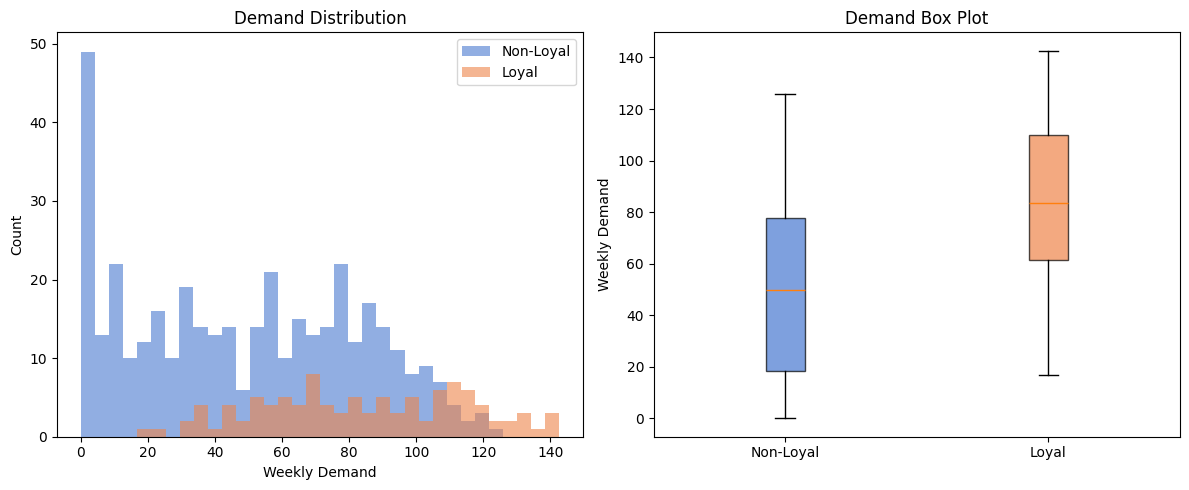

In [34]:
plot_demand_distribution(historic)
plt.show()


In [35]:
distance_sensitivity_table(historic)


,Pearson r,Slope (demand / dist unit)
Group,,
Non-Loyal,-0.279,-0.805
Loyal,0.013,0.055


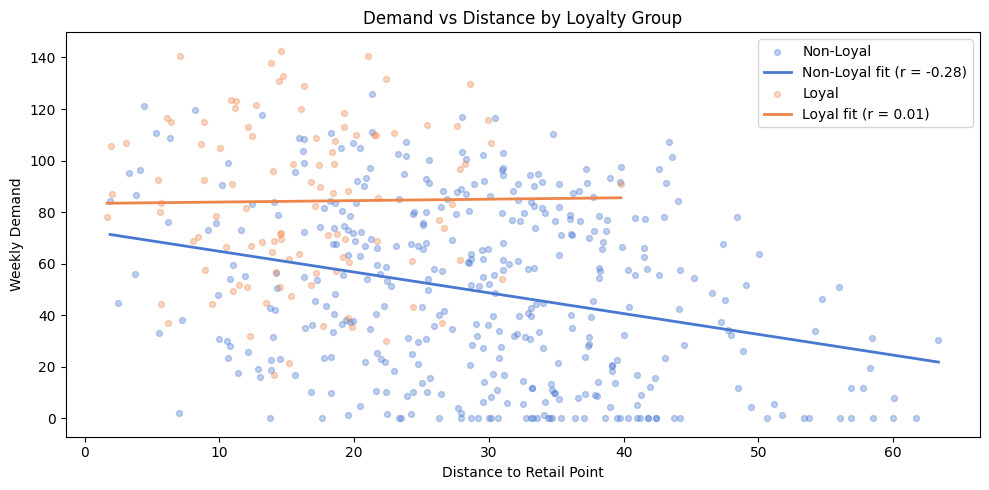

In [36]:
plot_demand_vs_distance(historic)
plt.show()


In [37]:
feature_means(historic)


,employes,surface,firm_age,monthly_volume,purchase_staff,dist_retail_point
loyal,,,,,,
Non-Loyal,230.48,1018.85,24.96,79.46,4.92,29.51
Loyal,333.15,1121.68,26.97,91.02,4.98,16.12


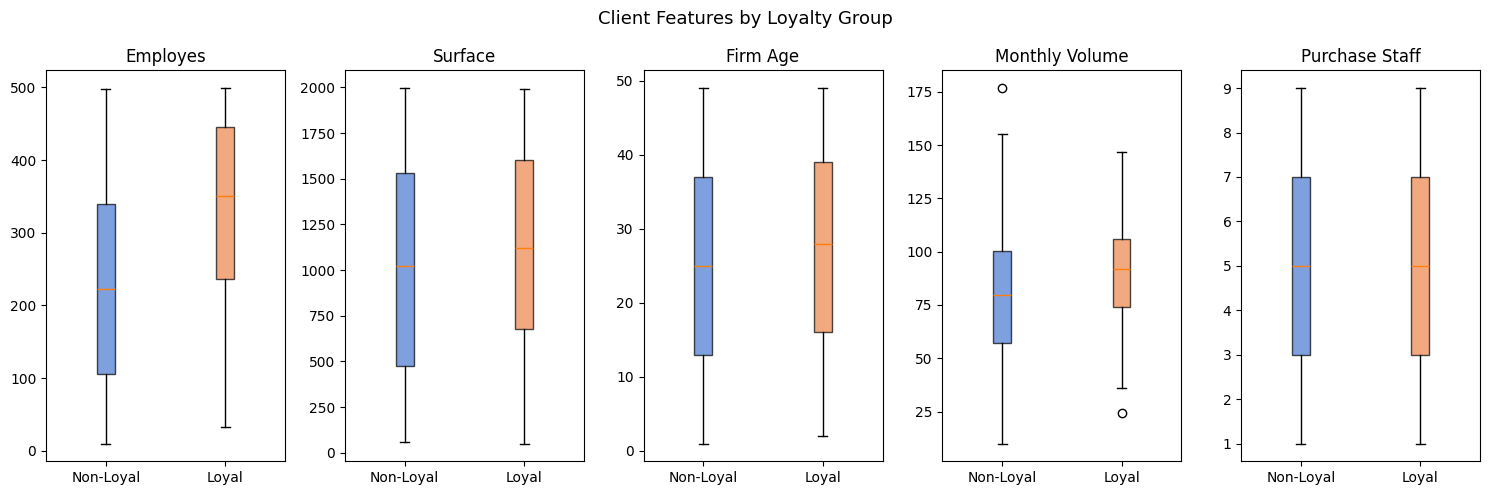

In [38]:
plot_feature_comparison(historic)
plt.show()


**EDA takeaway.** Loyal clients have higher weekly demand and different distance behavior. This supports the Stage 2 decision to classify potential clients by loyalty and then use separate demand models for each segment.

## 2. Loyalty Classifier

The classifier is evaluated on a train/test split. After choosing the final model, we refit it on all historical data before predicting loyalty for Valmontier.

In [39]:
X_train, X_test, y_train, y_test = split_loyalty_data(historic, test_size=0.2)
print(f"Train samples: {len(X_train)}")
print(f"Test samples : {len(X_test)}")
print(f"Loyal share in test set: {y_test.mean():.1%}")


Train samples: 400
Test samples : 100
Loyal share in test set: 21.0%


In [40]:
lr, rf = train_classifiers(X_train, y_train)
classifier_names = ["Logistic Regression", "Random Forest"]
classifiers = [lr, rf]

classification_evaluation_report(classifiers, classifier_names, X_test, y_test)


 Logistic Regression   (ROC AUC = 0.857)
              precision    recall  f1-score   support

   Non-Loyal       0.94      0.81      0.87        79
       Loyal       0.53      0.81      0.64        21

    accuracy                           0.81       100
   macro avg       0.74      0.81      0.76       100
weighted avg       0.86      0.81      0.82       100

 Random Forest   (ROC AUC = 0.866)
              precision    recall  f1-score   support

   Non-Loyal       0.86      0.96      0.91        79
       Loyal       0.75      0.43      0.55        21

    accuracy                           0.85       100
   macro avg       0.81      0.70      0.73       100
weighted avg       0.84      0.85      0.83       100



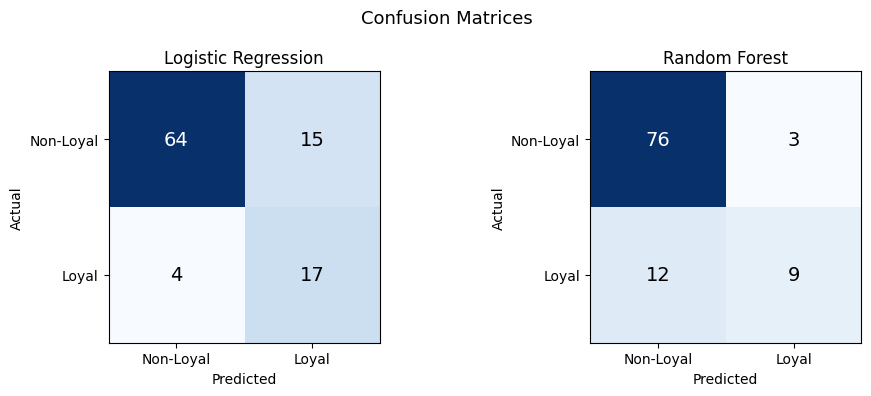

In [41]:
plot_confusion_matrices(classifiers, classifier_names, X_test, y_test)
plt.show()


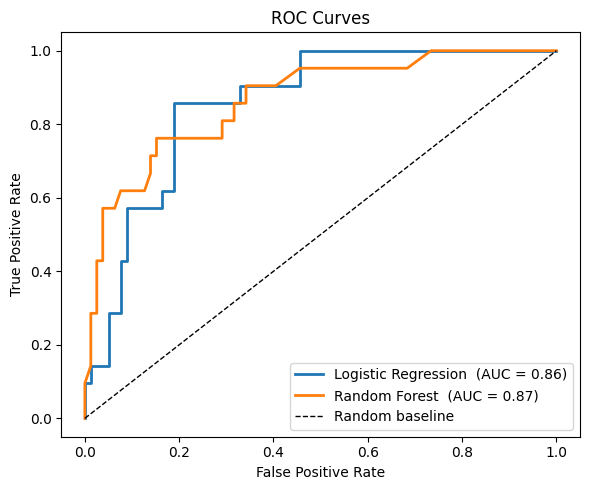

In [42]:
plot_roc_curves(classifiers, classifier_names, X_test, y_test)
plt.show()


We use logistic regression for the final loyalty matrix because it has stronger recall for the loyal class while keeping similar ROC-AUC. Missing loyal clients is costly because loyal clients tend to have higher demand.

In [43]:
final_classifier = train_final_classifier(historic)
loyalty_matrix = build_loyalty_matrix(final_classifier, potential, sites)

print(f"Loyalty matrix shape: {loyalty_matrix.shape}")
print(f"Predicted loyal share across all client-site pairs: {loyalty_matrix.mean():.1%}")
print(loyalty_matrix[:5])


Loyalty matrix shape: (200, 8)
Predicted loyal share across all client-site pairs: 12.1%
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 1 0 0 0 0 0 0]]


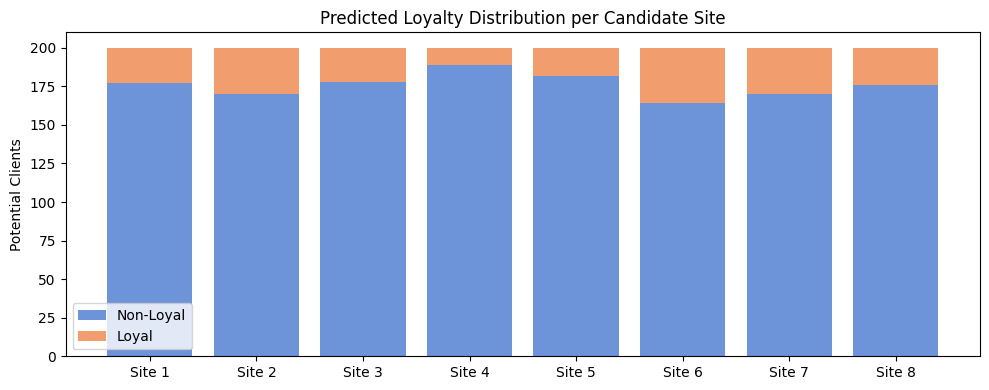

In [44]:
plot_loyalty_matrix_summary(loyalty_matrix)
plt.show()


In [45]:
loyalty_path = save_loyalty_matrix(loyalty_matrix)
print(f"Saved loyalty matrix to: {loyalty_path}")


Saved loyalty matrix to: outputs\loyalty_matrix_stage2.xlsx


## 3. Segmented Demand Models

We evaluate separate linear regressions for loyal and non-loyal clients. Then we refit the final models on all historical observations in each segment before generating the Stage 2 demand matrix.

In [46]:
loyal, nonloyal = split_by_loyalty(historic)
print(f"Loyal clients    : {len(loyal)}")
print(f"Non-loyal clients: {len(nonloyal)}")

splits = get_demand_splits(loyal, nonloyal)
evaluation_models = train_demand_models(splits)
demand_evaluation_report(evaluation_models, splits)


Loyal clients    : 105
Non-loyal clients: 395
Group            R2     RMSE
----------------------------
Loyal         0.958     6.78
Non-Loyal     0.939     8.01


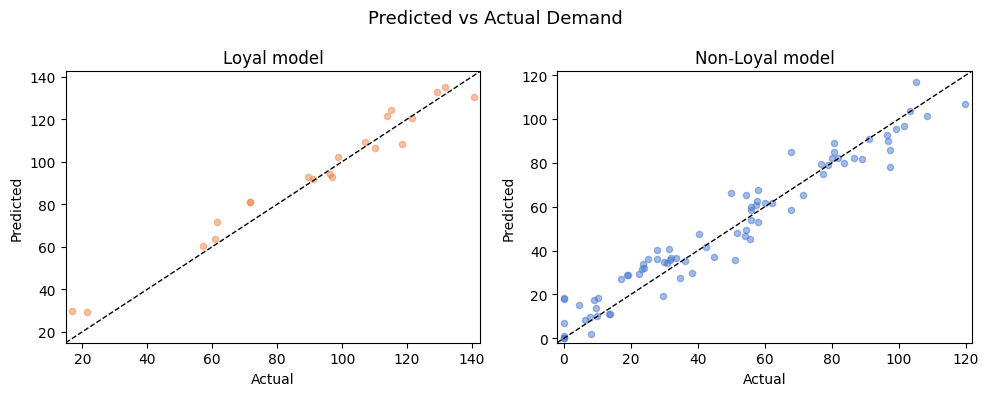

In [47]:
plot_predictions_vs_actual(evaluation_models, splits)
plt.show()


In [48]:
final_demand_models = train_final_demand_models(loyal, nonloyal)
demand_matrix_s2 = build_demand_matrix(final_demand_models, loyalty_matrix, potential, sites)

print(f"Demand matrix shape : {demand_matrix_s2.shape}")
print(f"Overall mean demand : {demand_matrix_s2.mean():.2f}")
print(f"Zero-demand entries : {(demand_matrix_s2 == 0).sum()} ({(demand_matrix_s2 == 0).mean():.1%})")


Demand matrix shape : (200, 8)
Overall mean demand : 38.44
Zero-demand entries : 350 (21.9%)


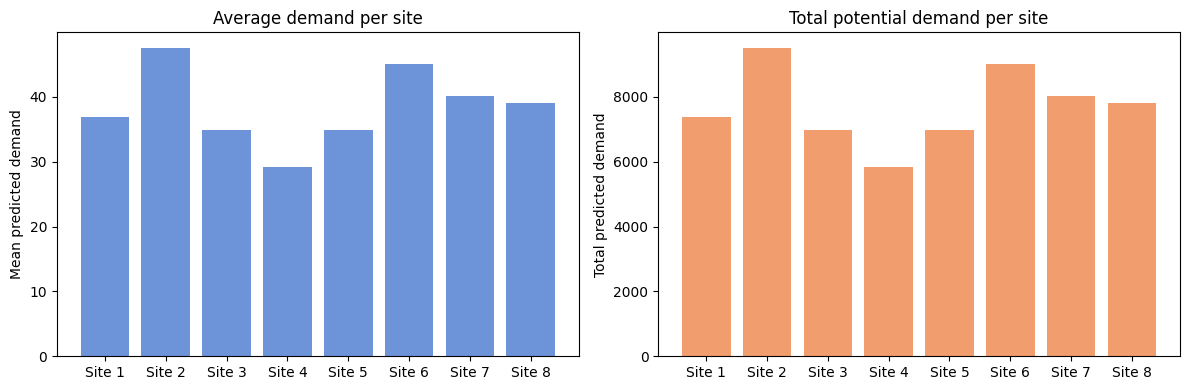

In [49]:
plot_demand_matrix_summary(demand_matrix_s2)
plt.show()


In [50]:
demand_path = save_demand_matrix(demand_matrix_s2, "demand_matrix_stage2.xlsx")
print(f"Saved Stage 2 demand matrix to: {demand_path}")


Saved Stage 2 demand matrix to: outputs\demand_matrix_stage2.xlsx


## 4. Stage 2 Optimization

The mathematical optimization model is unchanged from Stage 1. Only the demand matrix changes.

In [51]:
result_s2 = run_optimization(demand_matrix_s2, sites, budget=850, verbose=False)
print_summary(result_s2)


Total captured demand : 13061.3 units/week
Budget used           : 806 / 850 kEUR
Clients assigned      : 189 / 200
Clients unassigned    : 11

site_id format  capacity  cost  used_capacity  capacity_utilization
 Site 1  small    2500.0 144.0    1898.818712              0.759527
 Site 2  small    2800.0 158.0    2787.833388              0.995655
 Site 5  small    2500.0 144.0    2268.321446              0.907329
 Site 7  large    4200.0 207.0    3531.406622              0.840811
 Site 8  small    2700.0 153.0    2574.920263              0.953674


### 4.1 Selected Sites and Store Formats


In [52]:
selected_sites_s2 = result_s2["selected_sites"]
selected_sites_s2



,site_id,format,capacity,cost,used_capacity,capacity_utilization
0,Site 1,small,2500.0,144.0,1898.818712,0.759527
1,Site 2,small,2800.0,158.0,2787.833388,0.995655
2,Site 5,small,2500.0,144.0,2268.321446,0.907329
3,Site 7,large,4200.0,207.0,3531.406622,0.840811
4,Site 8,small,2700.0,153.0,2574.920263,0.953674


### 4.2 Client Assignments


In [53]:
assignments_s2 = result_s2["assignments"]
assignments_s2.head(10)



,client_id,site_id,captured_demand
0,1,Site 2,17.689203
1,2,Site 8,26.103721
2,3,Site 5,84.914800
3,4,Site 2,64.577502
4,5,Site 8,73.624344
5,6,Site 8,27.863369
6,7,Site 7,104.973552
7,8,Site 1,56.686948
8,9,Site 5,117.493373
9,10,Site 2,109.326475


In [54]:
result_path = save_optimization_results(result_s2, "stage2_optimization_results.xlsx")
print(f"Saved Stage 2 optimization results to: {result_path}")


Saved Stage 2 optimization results to: outputs\stage2_optimization_results.xlsx


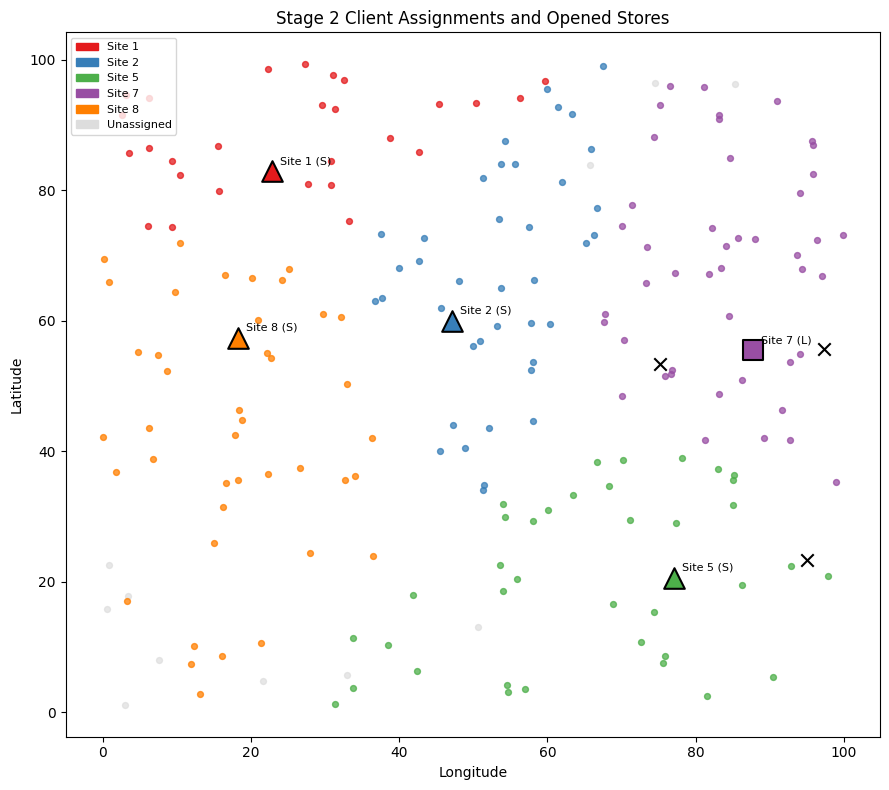

In [55]:
plot_assignment_map(result_s2, potential, sites, "Stage 2 Client Assignments and Opened Stores")
plt.show()


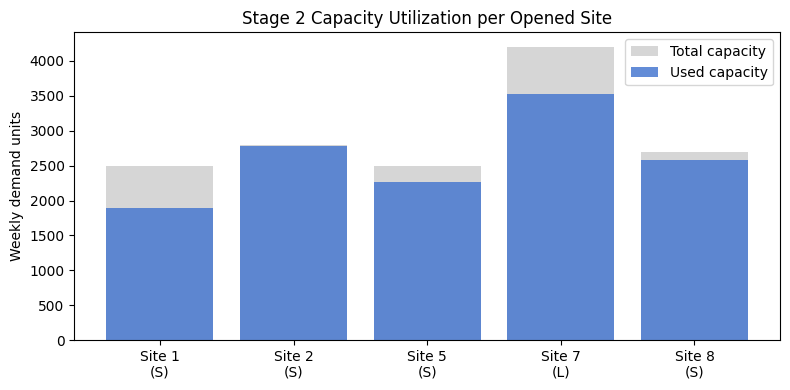

In [56]:
plot_capacity_utilization(result_s2, "Stage 2 Capacity Utilization per Opened Site")
plt.show()


## 5. Comparison with Stage 1

Stage 1 and Stage 2 use the same optimization model. The comparison isolates the effect of changing the demand-estimation approach.

Run `Stage1_Final.ipynb` first so `outputs/stage1_optimization_results.xlsx` exists. The comparison below reads the saved Stage 1 Excel results instead of rerunning the Stage 1 optimization.

In [57]:
result_s1 = load_optimization_results("stage1_optimization_results.xlsx")
result_s2 = load_optimization_results("stage2_optimization_results.xlsx")

compare_results(result_s1, result_s2, label1="Stage 1", label2="Stage 2")



Metric                          Stage 1                 Stage 2               
------------------------------------------------------------------------------
Predicted captured demand       12696.9                 13061.3               
Budget used (kEUR)              806 / 850               806 / 850             
Clients assigned                189 / 200               189 / 200             
Clients unassigned              11                      11                    
Stores opened                   5                       5                     
Sites selected                  Site 1(S), Site 2(S), Site 5(S), Site 7(L), Site 8(S)  Site 1(S), Site 2(S), Site 5(S), Site 7(L), Site 8(S)


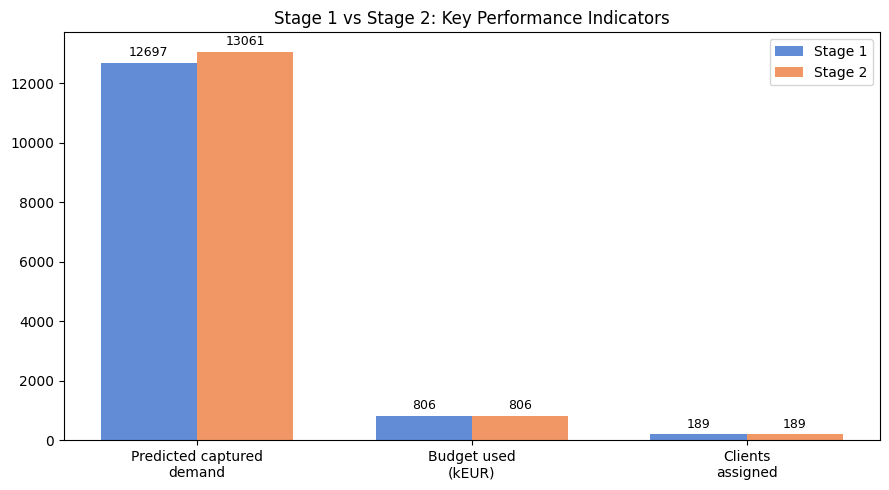

In [58]:
plot_comparison(result_s1, result_s2, label1="Stage 1", label2="Stage 2")
plt.show()


### 5.1 Site-Level Comparison

The aggregate KPI comparison shows whether Stage 2 changes total predicted demand. The table below checks whether the same sites and formats are selected, and how each opened store changes in demand and capacity utilization.


In [59]:
site_comparison = display_site_comparison(result_s1, result_s2)
site_comparison



,site,format_s1,format_s2,capacity_s1,capacity_s2,demand_s1,demand_s2,demand_change,utilization_s1,utilization_s2,utilization_change_pp,cost_s1,cost_s2,same_format
0,Site 1,small,small,2500,2500,1918.5,1898.8,-19.7,76.7,76.0,-0.8,144,144,True
1,Site 2,small,small,2800,2800,2780.0,2787.8,7.8,99.3,99.6,0.3,158,158,True
2,Site 5,small,small,2500,2500,2218.1,2268.3,50.2,88.7,90.7,2.0,144,144,True
3,Site 7,large,large,4200,4200,3434.6,3531.4,96.8,81.8,84.1,2.3,207,207,True
4,Site 8,small,small,2700,2700,2345.6,2574.9,229.3,86.9,95.4,8.5,153,153,True


In [ ]:
site_comparison_insights(result_s1, result_s2)

Same opened sites and formats: yes
Total predicted captured demand change: 364.4 units/week
Largest site-level demand increase: Site 8 (+229.3 units/week)
Largest utilization increase: Site 8 (8.5 percentage points)


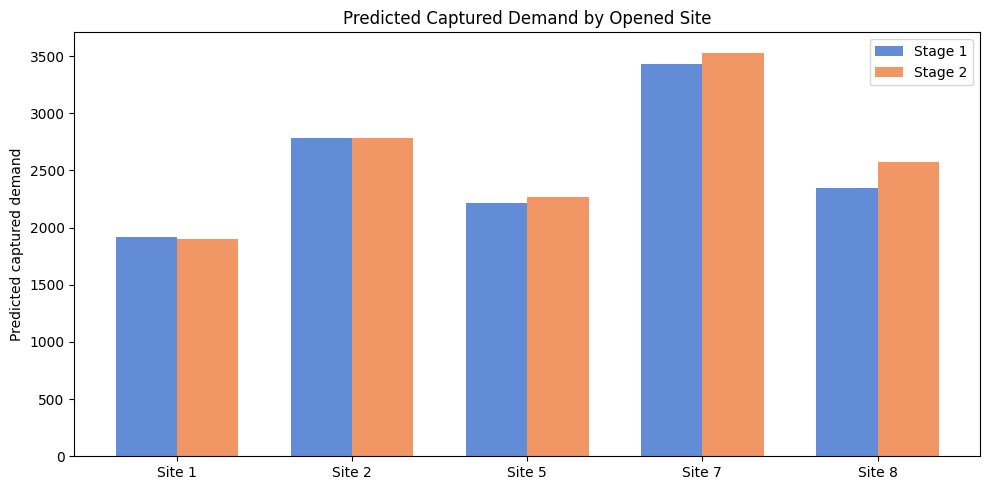

In [ ]:
plot_site_demand_comparison(result_s1, result_s2)
plt.show()

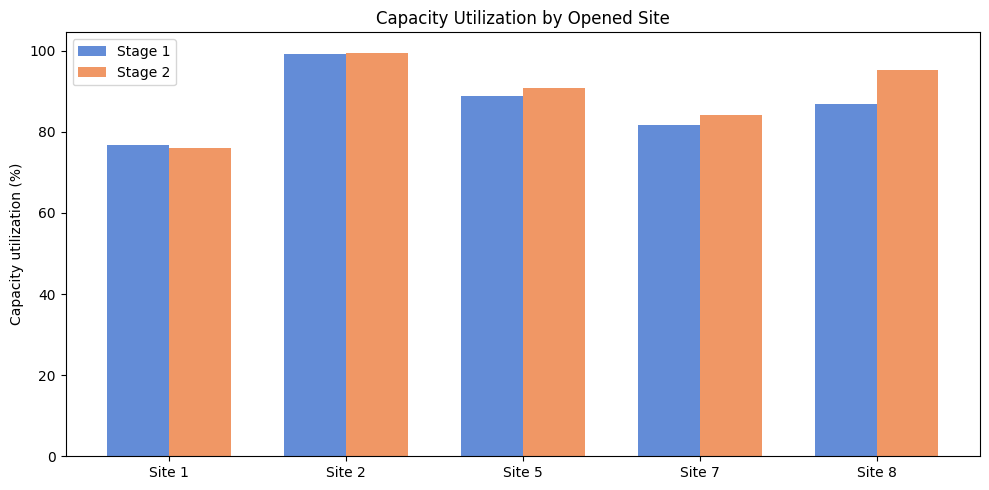

In [ ]:
plot_site_utilization_comparison(result_s1, result_s2)
plt.show()

## 6. Interpretation

### Retail store site decision

Both stages converge on the exact same 5-store configuration: Site 1, Site 2, Site 5, Site 7, and Site 8, with Site 7 opened as a large store and the others opened as small stores. Both solutions spend 806 kEUR out of the 850 kEUR budget and assign 189 out of 200 clients. So the optimizer did not need a different layout to benefit from the segmented approach.

### Difference in approach

The difference we can see is mainly in how much demand each site is predicted to capture.

Stage 2 extracts 13,061 units/week versus 12,697 for Stage 1. This is a gain of around +364 units/week, or +2.9%, at zero extra cost because the site assignment and store configuration are the same. The utilization improvement is not perfectly uniform across every site, but it is most visible at Site 8, which increases from 86.9% to 95.4%, and Site 7, which increases from 81.8% to 84.1%.

The apparent reason behind this is that Stage 1 trained a single OLS model over all clients, so the distance penalty it learned is an average of both groups. This averaged penalty can undervalue loyal clients if loyal customers are less sensitive to distance or have structurally higher demand.

Stage 2 sends each client-site pair through the appropriate segmented demand model after predicting loyalty, so loyal and non-loyal clients are scored closer to their own demand behavior instead of being forced into one global relationship.

### Final interpretation

The segmented approach is the better modeling choice. It decides on the same stores, same budget, and same coverage as Stage 1, but predicts more captured demand from the same network. This gain is modest in percentage terms, but it represents additional expected weekly demand for no extra investment and shows that the store-opening decision is robust while the demand estimation improves.

